<a href="https://colab.research.google.com/github/Kripa-Garg/sms-spam-classifier/blob/main/spam_classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SMS Spam Classifier

## 1. Load and Explore Data

In [ ]:
# import the libraries we need today
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/SPAM_DATASET.zip', encoding='latin-1')

In [ ]:
print(df.shape)       # how many rows and columns?
print(df.head())      # show first 5 rows

(5572, 5)
     v1                                                 v2 Unnamed: 2  \
0   ham  Go until jurong point, crazy.. Available only ...        NaN   
1   ham                      Ok lar... Joking wif u oni...        NaN   
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...        NaN   
3   ham  U dun say so early hor... U c already then say...        NaN   
4   ham  Nah I don't think he goes to usf, he lives aro...        NaN   

  Unnamed: 3 Unnamed: 4  
0        NaN        NaN  
1        NaN        NaN  
2        NaN        NaN  
3        NaN        NaN  
4        NaN        NaN  


In [ ]:
# keep only v1 and v2, rename them to something readable
df = df[['v1', 'v2']]
df.columns = ['label', 'text']

# add a numeric column: ham=0, spam=1
df['label_num'] = df['label'].map({'ham': 0, 'spam': 1})

print(df.head())
print(df.shape)  # should now be (5572, 3)

  label                                               text  label_num
0   ham  Go until jurong point, crazy.. Available only ...          0
1   ham                      Ok lar... Joking wif u oni...          0
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...          1
3   ham  U dun say so early hor... U c already then say...          0
4   ham  Nah I don't think he goes to usf, he lives aro...          0
(5572, 3)


In [ ]:
# count spam vs ham
print(df['label'].value_counts())
print()
print(df['label'].value_counts(normalize=True) * 100)  # as percentages

label
ham     4825
spam     747
Name: count, dtype: int64

label
ham     86.593683
spam    13.406317
Name: proportion, dtype: float64


label
ham      71.023627
spam    138.866131
Name: msg_length, dtype: float64


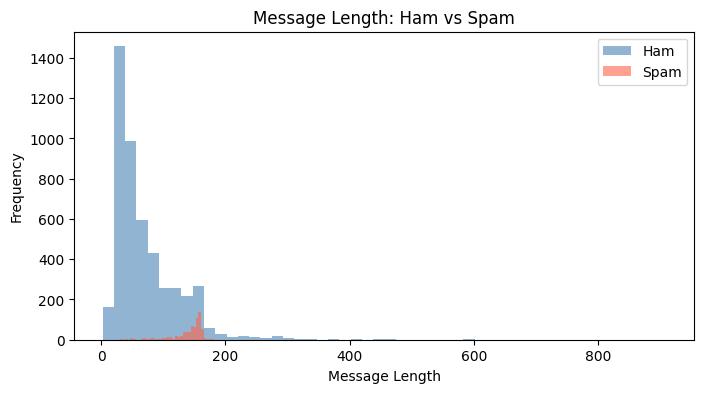

In [ ]:
# add a column for message length
df['msg_length'] = df['text'].apply(len)

# compare average length
print(df.groupby('label')['msg_length'].mean())

# visualise it
plt.figure(figsize=(8, 4))
df[df['label']=='ham']['msg_length'].plot(kind='hist', bins=50,
    alpha=0.6, label='Ham', color='steelblue')
df[df['label']=='spam']['msg_length'].plot(kind='hist', bins=50,
    alpha=0.6, label='Spam', color='tomato')
plt.xlabel('Message Length')
plt.title('Message Length: Ham vs Spam')
plt.legend()
plt.show()

In [ ]:
# see 5 random spam messages
print(df[df['label']=='spam']['text'].sample(5).values)

# see 5 random ham messages
print(df[df['label']=='ham']['text'].sample(5).values)

['You have won ?1,000 cash or a ?2,000 prize! To claim, call09050000327'
 "Free entry in 2 a weekly comp for a chance to win an ipod. Txt POD to 80182 to get entry (std txt rate) T&C's apply 08452810073 for details 18+"
 'Shop till u Drop, IS IT YOU, either 10K, 5K, å£500 Cash or å£100 Travel voucher, Call now, 09064011000. NTT PO Box CR01327BT fixedline Cost 150ppm mobile vary'
 "Collect your VALENTINE'S weekend to PARIS inc Flight & Hotel + å£200 Prize guaranteed! Text: PARIS to No: 69101. www.rtf.sphosting.com"
 'Your free ringtone is waiting to be collected. Simply text the password \\MIX\\" to 85069 to verify. Get Usher and Britney. FML']
['Haha awesome, be there in a minute'
 'They just talking thats it de. They wont any other.'
 'Can you plz tell me the ans. BSLVYL sent via fullonsms.com'
 'Just now saw your message.it k da:)'
 'I can send you a pic if you like :)']


## 2. Text Preprocessing

In [ ]:
import nltk
import re
nltk.download('stopwords')
from nltk.corpus import stopwords

# see what stopwords look like
stop_words = set(stopwords.words('english'))
print(list(stop_words)[:20])

['so', "hadn't", "didn't", 'no', 'its', "we'd", "we're", 'below', "she's", 'up', "it'll", 'didn', "haven't", "shouldn't", 'ma', 'herself', "he'll", 'd', 'shouldn', 'am']


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:
def clean_text(text):
    # 1. lowercase everything
    text = text.lower()

    # 2. remove numbers and punctuation — keep only letters and spaces
    text = re.sub(r'[^a-z\s]', '', text)

    # 3. remove stopwords
    words = text.split()
    words = [w for w in words if w not in stop_words]

    return ' '.join(words)

# test it on one message
sample = "FREE entry in 2 a weekly competition to win FA Cup final tkts!"
print(clean_text(sample))

free entry weekly competition win fa cup final tkts


In [ ]:
# apply to every row — this takes about 3 seconds
df['clean_text'] = df['text'].apply(clean_text)

# compare before and after
print("BEFORE:", df['text'][0])
print("AFTER: ", df['clean_text'][0])

BEFORE: Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...
AFTER:  go jurong point crazy available bugis n great world la e buffet cine got amore wat


## 3. TF-IDF Vectorisation

What is TF-IDF? (understand this for interviews)

TF (Term Frequency): how often a word appears in this message. If "free" appears 3 times in a 10-word message, TF = 0.3.

IDF (Inverse Document Frequency): how rare is the word across ALL messages? "free" in spam but not in ham = high IDF. "the" is everywhere = low IDF.

TF-IDF = TF × IDF. Words that are common in this message AND rare across all messages get a high score. That's what makes spam words stand out.

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

# TF-IDF: max 3000 features, include single words AND pairs (bigrams)
# bigrams catch things like "free money", "click here", "win prize"
tfidf = TfidfVectorizer(max_features=3000, ngram_range=(1, 2))

# X = features (the text), y = labels (0 or 1)
X = tfidf.fit_transform(df['clean_text'])
y = df['label_num']

print("Shape of X:", X.shape)
# you should see (5572, 3000) — 5572 messages, 3000 features each

Shape of X: (5572, 3000)


## 4. Model Training and Evaluation

In [ ]:
# 80% for training, 20% for testing
# stratify=y ensures both splits have the same 87/13 spam ratio
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print("Training size:", X_train.shape[0])
print("Testing size: ", X_test.shape[0])

Training size: 4457
Testing size:  1115


In [ ]:
# Train Naïve Bayes, Logistic Regression, SVM
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# define all 3 models
models = {
    'Naive Bayes':         MultinomialNB(),
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'SVM':                 LinearSVC()
}

# train and evaluate each one
results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    results[name] = y_pred
    print(f"\n{'='*40}")
    print(f"  {name}")
    print('='*40)
    print(classification_report(y_test, y_pred,target_names=['Ham', 'Spam']))


  Naive Bayes
              precision    recall  f1-score   support

         Ham       0.97      1.00      0.99       966
        Spam       0.99      0.82      0.90       149

    accuracy                           0.97      1115
   macro avg       0.98      0.91      0.94      1115
weighted avg       0.98      0.97      0.97      1115


  Logistic Regression
              precision    recall  f1-score   support

         Ham       0.96      1.00      0.98       966
        Spam       0.97      0.77      0.86       149

    accuracy                           0.97      1115
   macro avg       0.97      0.88      0.92      1115
weighted avg       0.97      0.97      0.96      1115


  SVM
              precision    recall  f1-score   support

         Ham       0.98      1.00      0.99       966
        Spam       1.00      0.90      0.95       149

    accuracy                           0.99      1115
   macro avg       0.99      0.95      0.97      1115
weighted avg       0.99      

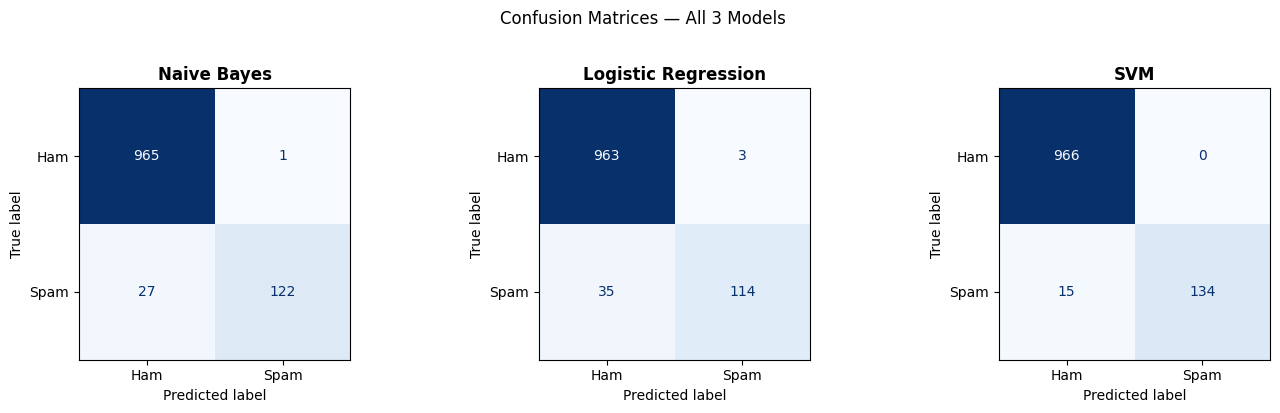

In [ ]:
# Plot confusion matrix for each model
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, (name, y_pred) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm,
               display_labels=['Ham', 'Spam'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name, fontsize=12, fontweight='bold')

plt.suptitle('Confusion Matrices — All 3 Models', y=1.02)
plt.tight_layout()
plt.savefig('confusion_matrices.png', bbox_inches='tight', dpi=150)
plt.show()


## 5. Results and Conclusion

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print(f"{'Model':<22} {'Accuracy':>9} {'Precision':>10} {'Recall':>8} {'F1':>6}")
print("-" * 58)

for name, y_pred in results.items():
    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec  = recall_score(y_test, y_pred)
    f1   = f1_score(y_test, y_pred)
    print(f"{name:<22} {acc:>9.3f} {prec:>10.3f} {rec:>8.3f} {f1:>6.3f}")

Model                   Accuracy  Precision   Recall     F1
----------------------------------------------------------
Naive Bayes                0.975      0.992    0.819  0.897
Logistic Regression        0.966      0.974    0.765  0.857
SVM                        0.987      1.000    0.899  0.947
